# SmogAlert PK — Cleaned Dataset Display

This notebook loads and explores `cleaned_data.csv` produced by `src/preprocess.py`.

**Dataset covers**: 5 Pakistani cities × 8 pollutants × Aug 2021 – Dec 2024  
**Source**: Kaggle `hajramohsin/pakistan-air-quality-pollutant-concentrations`

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Make tables wider and plots larger so they're easier to read
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

# ── Load cleaned dataset ──────────────────────────────────────────────────────
# This notebook lives inside data/, so the path is relative to that folder
CLEANED_FILE = 'cleaned_data.csv'

df = pd.read_csv(CLEANED_FILE, parse_dates=['timestamp'])

print(f'Loaded {len(df):,} rows x {len(df.columns)} columns from {CLEANED_FILE}')

Loaded 127,551 rows x 20 columns from cleaned_data.csv


## 1. Schema Overview

In [2]:
# Column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 127551 entries, 0 to 127550
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   timestamp     127551 non-null  datetime64[us]
 1   city          127551 non-null  str           
 2   pm25          127551 non-null  float64       
 3   pm10          127551 non-null  float64       
 4   no            127551 non-null  float64       
 5   no2           127551 non-null  float64       
 6   so2           127551 non-null  float64       
 7   nh3           127551 non-null  float64       
 8   co            127551 non-null  float64       
 9   o3            127551 non-null  float64       
 10  hour          127551 non-null  int64         
 11  day_of_week   127551 non-null  int64         
 12  month         127551 non-null  int64         
 13  season        127551 non-null  str           
 14  city_season   127551 non-null  str           
 15  is_weekend    127551 non-nul

In [3]:
# First 10 rows
df.head(10)

,timestamp,city,pm25,pm10,no,no2,so2,nh3,co,o3,hour,day_of_week,month,season,city_season,is_weekend,pm25_24h_avg,pm10_24h_avg,aqi_category,split
0,2021-08-24 00:00:00,Islamabad,66.96,87.07,0.00,27.76,6.02,14.69,1228.33,40.41,0,1,8,Summer,Islamabad_Summer,0,66.96,87.07,Moderate,train
1,2021-08-24 01:00:00,Islamabad,64.50,82.37,0.00,24.33,6.20,14.57,1134.87,46.49,1,1,8,Summer,Islamabad_Summer,0,65.73,84.72,Moderate,train
2,2021-08-24 02:00:00,Islamabad,64.21,80.38,0.94,39.41,6.91,16.21,1361.85,30.76,2,1,8,Summer,Islamabad_Summer,0,65.22,83.27,Moderate,train
3,2021-08-24 03:00:00,Islamabad,64.75,79.55,8.38,51.41,9.06,17.73,1682.28,27.18,3,1,8,Summer,Islamabad_Summer,0,65.10,82.34,Moderate,train
4,2021-08-24 04:00:00,Islamabad,59.86,71.18,3.07,27.08,21.70,13.30,1054.76,91.55,4,1,8,Summer,Islamabad_Summer,0,64.06,80.11,Moderate,train
5,2021-08-24 05:00:00,Islamabad,63.68,74.63,2.32,19.71,26.94,12.41,934.60,131.61,5,1,8,Summer,Islamabad_Summer,0,63.99,79.20,Moderate,train
6,2021-08-24 06:00:00,Islamabad,69.67,80.41,1.26,13.02,24.32,12.03,834.47,180.24,6,1,8,Summer,Islamabad_Summer,0,64.80,79.37,Moderate,train
7,2021-08-24 07:00:00,Islamabad,66.53,77.03,0.57,6.34,13.95,10.77,694.28,191.69,7,1,8,Summer,Islamabad_Summer,0,65.02,79.08,Moderate,train
8,2021-08-24 08:00:00,Islamabad,62.03,72.65,0.50,5.23,10.73,10.01,647.54,181.68,8,1,8,Summer,Islamabad_Summer,0,64.69,78.36,Moderate,train
9,2021-08-24 09:00:00,Islamabad,60.56,71.47,0.55,5.74,10.73,9.88,654.22,181.68,9,1,8,Summer,Islamabad_Summer,0,64.28,77.67,Moderate,train


## 2. Date Range & Train / Test Split

In [ ]:
print(f'Earliest timestamp : {df["timestamp"].min()}')
print(f'Latest  timestamp  : {df["timestamp"].max()}')
print()

# Boundary: rows before 2024-07-01 = train, on/after = test
split_counts = df['split'].value_counts().rename_axis('split').reset_index(name='rows')
split_counts['pct'] = (split_counts['rows'] / len(df) * 100).round(1)
print('Train / test split:')
print(split_counts.to_string(index=False))

## 3. City Coverage

In [4]:
# Row count, date range, and train/test breakdown per city
city_summary = (
    df.groupby('city')
    .agg(
        rows       = ('timestamp', 'count'),
        start_date = ('timestamp', 'min'),
        end_date   = ('timestamp', 'max'),
        train_rows = ('split', lambda x: (x == 'train').sum()),
        test_rows  = ('split', lambda x: (x == 'test').sum()),
    )
    .sort_values('rows', ascending=False)
)
city_summary

,rows,start_date,end_date,train_rows,test_rows
city,,,,,
Lahore,29973,2021-08-24,2024-12-12 23:00:00,24646,5327
Islamabad,29949,2021-08-24,2024-12-12 23:00:00,24622,5327
Karachi,29925,2021-08-24,2024-12-12 23:00:00,24622,5303
Peshawar,18864,2021-08-24,2024-12-12 23:00:00,14952,3912
Quetta,18840,2021-08-24,2024-12-12 23:00:00,14952,3888


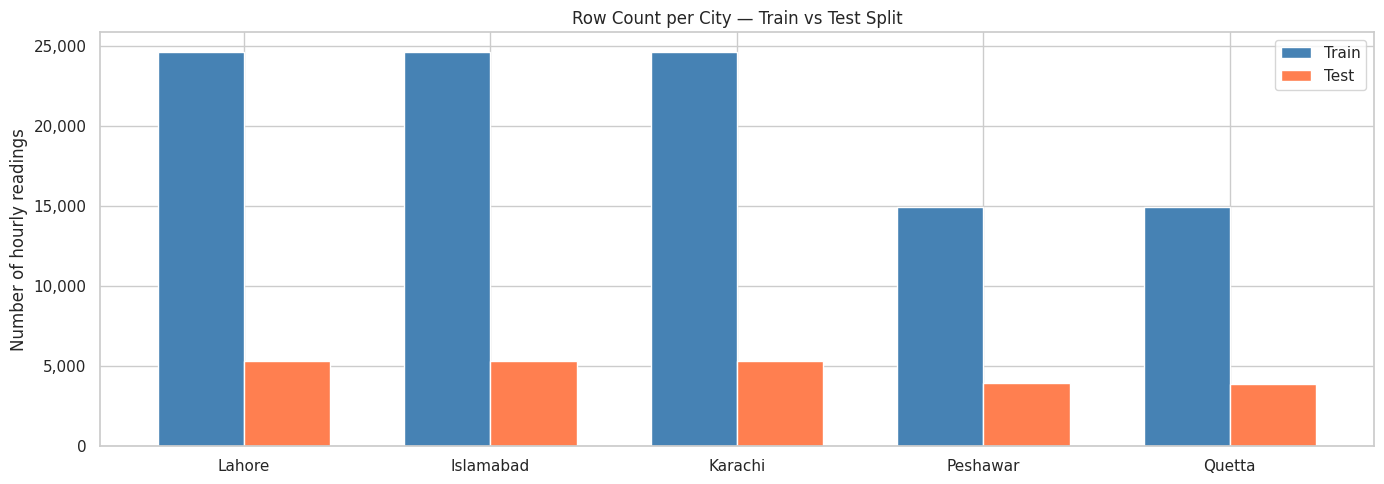

In [5]:
# Bar chart: row count per city, grouped by train vs test
fig, ax = plt.subplots()

cities     = city_summary.index.tolist()
train_vals = city_summary['train_rows'].values
test_vals  = city_summary['test_rows'].values
x          = np.arange(len(cities))
bar_width  = 0.35

ax.bar(x - bar_width / 2, train_vals, bar_width, label='Train', color='steelblue')
ax.bar(x + bar_width / 2, test_vals,  bar_width, label='Test',  color='coral')

ax.set_xticks(x)
ax.set_xticklabels(cities)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_title('Row Count per City — Train vs Test Split')
ax.set_ylabel('Number of hourly readings')
ax.legend()
plt.tight_layout()
plt.show()

## 4. AQI Category Distribution

In [6]:
AQI_ORDER  = ['Good', 'Moderate', 'Unhealthy', 'Hazardous']
AQI_COLORS = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']

aqi_counts = df['aqi_category'].value_counts().reindex(AQI_ORDER).fillna(0).astype(int)
aqi_pct    = (aqi_counts / len(df) * 100).round(1)

aqi_table = pd.DataFrame({'count': aqi_counts, 'pct_%': aqi_pct})
print('Overall AQI distribution:')
print(aqi_table.to_string())

Overall AQI distribution:
              count  pct_%
aqi_category              
Good          54564  42.80
Moderate      28109  22.00
Unhealthy     14335  11.20
Hazardous     30543  23.90


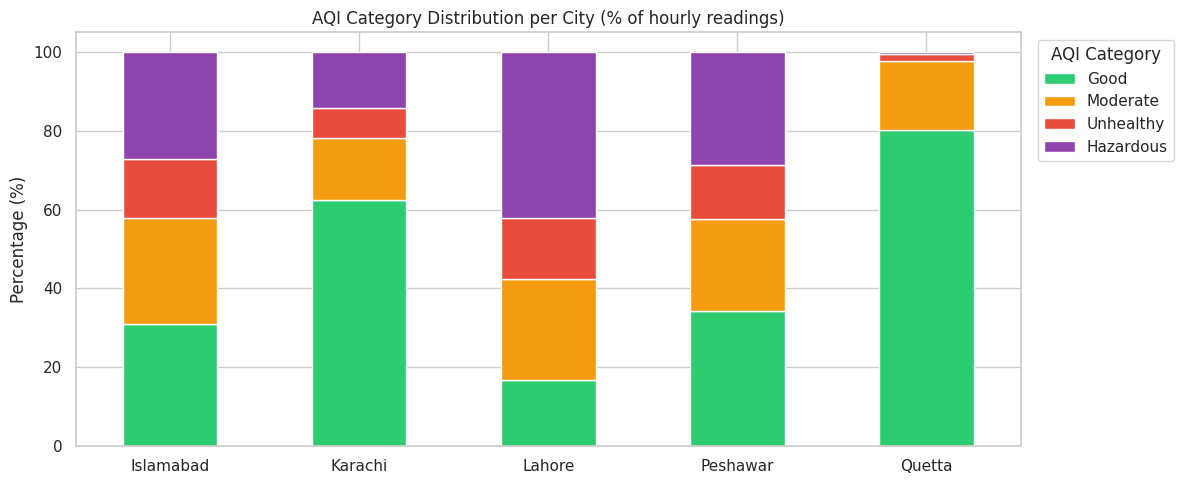

In [7]:
# Stacked bar: AQI distribution per city (normalised to % so cities are comparable)
city_aqi = (
    df.groupby(['city', 'aqi_category'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=AQI_ORDER, fill_value=0)
)
city_aqi_pct = city_aqi.div(city_aqi.sum(axis=1), axis=0) * 100

ax = city_aqi_pct.plot(
    kind='bar', stacked=True,
    color=AQI_COLORS,
    figsize=(12, 5)
)
ax.set_title('AQI Category Distribution per City (% of hourly readings)')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='AQI Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Season Distribution

In [8]:
SEASON_ORDER  = ['Winter', 'Spring', 'Summer', 'Autumn']
season_counts = df['season'].value_counts().reindex(SEASON_ORDER).fillna(0).astype(int)

print('Season distribution:')
for season, count in season_counts.items():
    bar = '\u2588' * (count // 2000)
    print(f'  {season:8}: {count:>7,}  {bar}')

print()
print('City-season group sizes (used for per-group Isolation Forest):')
cs_counts = df['city_season'].value_counts().sort_index()
print(cs_counts.to_string())

Season distribution:
  Winter  :  41,496  ████████████████████
  Spring  :  27,768  █████████████
  Summer  :  44,346  ██████████████████████
  Autumn  :  13,941  ██████

City-season group sizes (used for per-group Isolation Forest):
city_season
Islamabad_Autumn     3239
Islamabad_Spring     6576
Islamabad_Summer    10366
Islamabad_Winter     9768
Karachi_Autumn       3239
Karachi_Spring       6576
Karachi_Summer      10342
Karachi_Winter       9768
Lahore_Autumn        3239
Lahore_Spring        6600
Lahore_Summer       10366
Lahore_Winter        9768
Peshawar_Autumn      2112
Peshawar_Spring      4008
Peshawar_Summer      6648
Peshawar_Winter      6096
Quetta_Autumn        2112
Quetta_Spring        4008
Quetta_Summer        6624
Quetta_Winter        6096


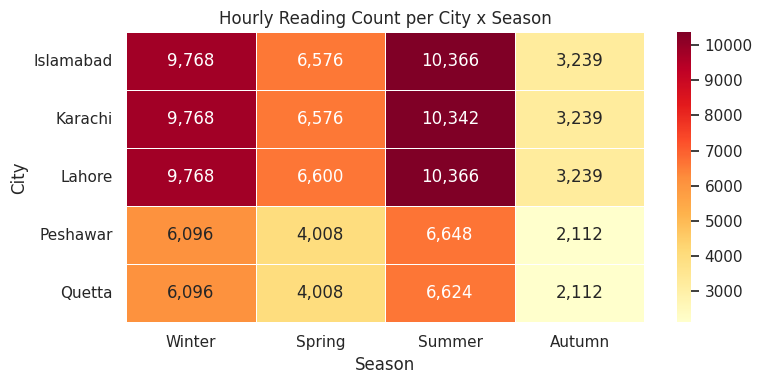

In [9]:
# Heatmap: row count per city x season
city_season_pivot = (
    df.groupby(['city', 'season'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SEASON_ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(
    city_season_pivot,
    annot=True, fmt=',d',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Hourly Reading Count per City x Season')
ax.set_ylabel('City')
ax.set_xlabel('Season')
plt.tight_layout()
plt.show()

## 6. Pollutant Summary Statistics

In [10]:
POLLUTANTS = ['pm25', 'pm10', 'no', 'no2', 'so2', 'nh3', 'co', 'o3']

# Summary statistics (count, mean, std, min, quartiles, max) for all 8 pollutants
pollutant_stats = df[POLLUTANTS].describe().T
pollutant_stats

,count,mean,std,min,25%,50%,75%,max
pm25,127551.00,117.87,147.39,0.50,29.09,62.49,143.72,1965.05
pm10,127551.00,161.94,170.99,0.57,57.32,103.50,198.55,2183.34
no,127551.00,20.95,49.01,0.00,0.02,1.08,14.19,686.65
no2,127551.00,51.16,56.50,0.00,10.02,30.16,75.40,833.51
so2,127551.00,13.83,14.80,0.16,4.05,9.18,18.36,165.94
nh3,127551.00,23.21,30.65,0.00,4.50,11.91,29.13,389.10
co,127551.00,2199.41,2536.65,150.20,527.38,1161.58,2937.32,27771.00
o3,127551.00,64.11,65.17,0.00,6.62,47.92,97.27,709.53


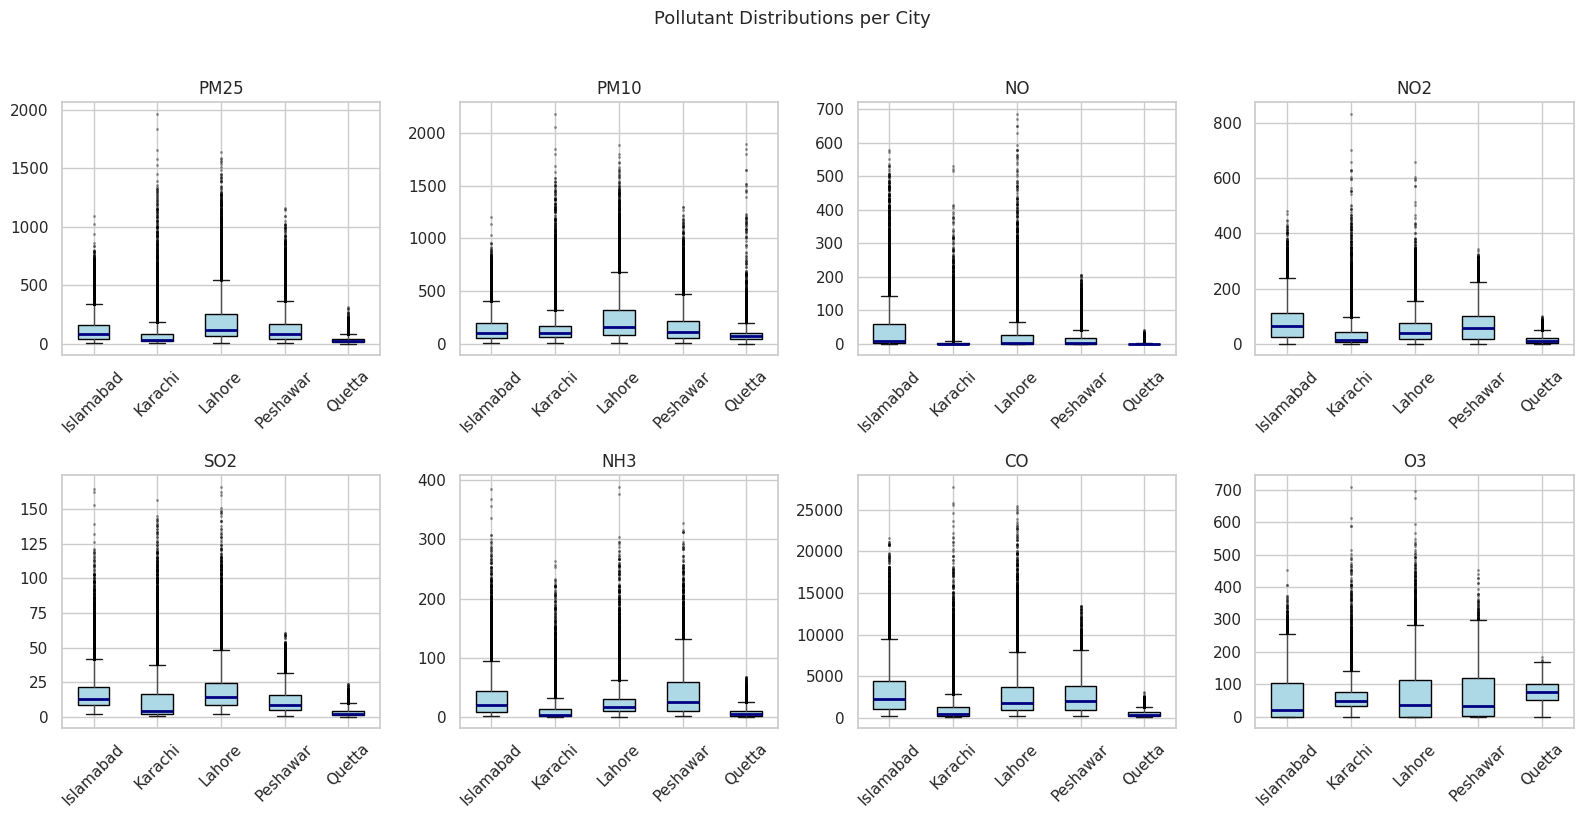

In [11]:
# Box plots: spread and outliers for each pollutant, broken down by city
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, pollutant in zip(axes.flat, POLLUTANTS):
    df.boxplot(
        column=pollutant, by='city',
        ax=ax, notch=False,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue'),
        medianprops=dict(color='navy', linewidth=2),
        flierprops=dict(marker='.', markersize=2, alpha=0.4)
    )
    ax.set_title(pollutant.upper())
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Pollutant Distributions per City', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. PM2.5 Monthly Trend per City

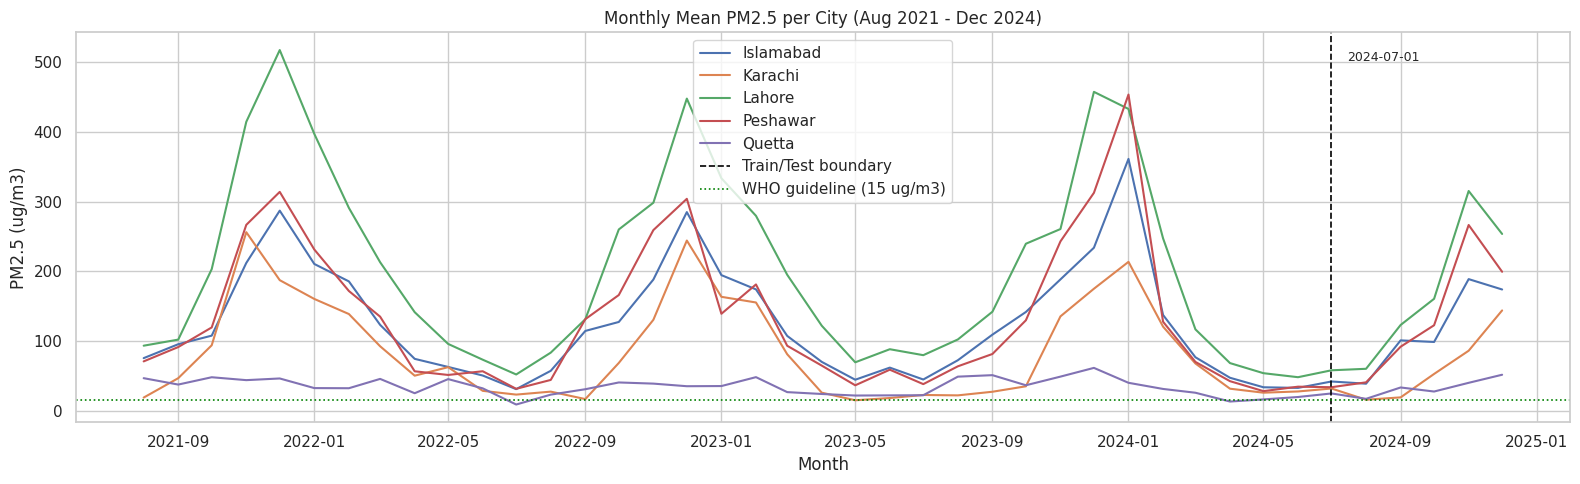

In [12]:
# Monthly mean PM2.5 — winter smog season typically peaks Nov-Jan
monthly_pm25 = (
    df.groupby(['city', df['timestamp'].dt.to_period('M')])
    ['pm25']
    .mean()
    .reset_index()
)
monthly_pm25.columns = ['city', 'month', 'mean_pm25']
monthly_pm25['month'] = monthly_pm25['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 5))

for city, group in monthly_pm25.groupby('city'):
    ax.plot(group['month'], group['mean_pm25'], label=city, linewidth=1.5)

# Mark the train/test boundary
ax.axvline(
    pd.Timestamp('2024-07-01'),
    color='black', linestyle='--', linewidth=1.2, label='Train/Test boundary'
)
ax.text(
    pd.Timestamp('2024-07-15'), ax.get_ylim()[1] * 0.95,
    '2024-07-01', va='top', fontsize=9
)

# WHO annual mean PM2.5 guideline
ax.axhline(15, color='green', linestyle=':', linewidth=1.2, label='WHO guideline (15 ug/m3)')

ax.set_title('Monthly Mean PM2.5 per City (Aug 2021 - Dec 2024)')
ax.set_ylabel('PM2.5 (ug/m3)')
ax.set_xlabel('Month')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Diurnal Cycle (Average PM2.5 by Hour)

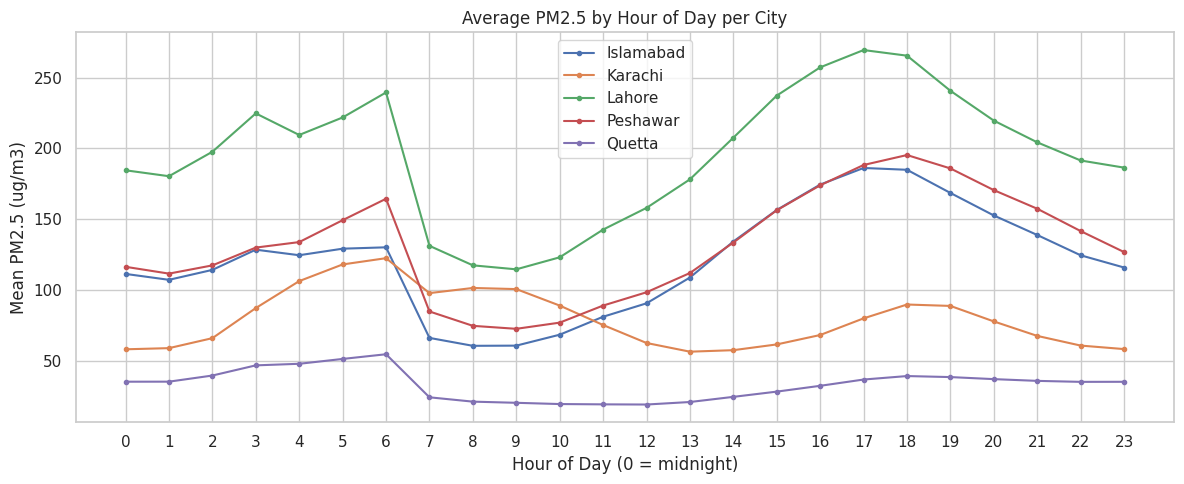

In [13]:
# Average PM2.5 by hour of day — shows morning and evening rush-hour peaks
hourly_pm25 = (
    df.groupby(['city', 'hour'])
    ['pm25']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for city, group in hourly_pm25.groupby('city'):
    ax.plot(group['hour'], group['pm25'], marker='o', markersize=3, label=city)

ax.set_title('Average PM2.5 by Hour of Day per City')
ax.set_ylabel('Mean PM2.5 (ug/m3)')
ax.set_xlabel('Hour of Day (0 = midnight)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.show()

## 9. Pollutant Correlation Matrix

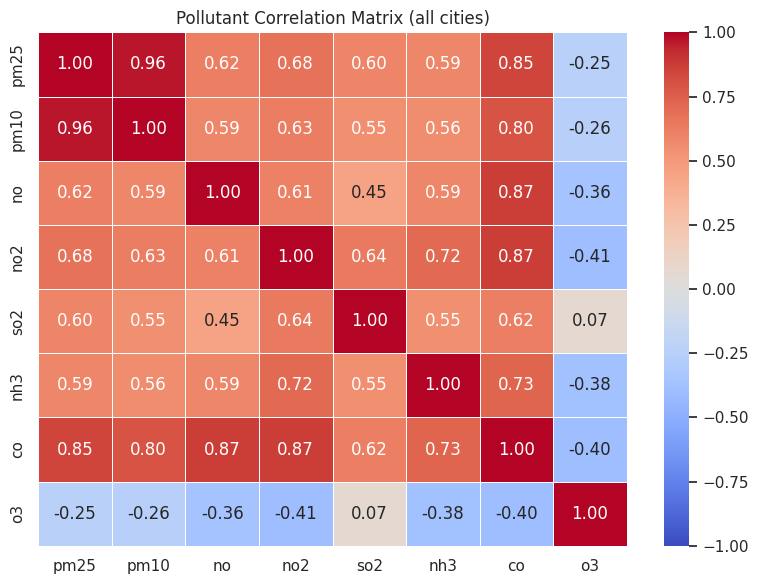

In [14]:
# Pearson correlation across all 8 pollutants (all cities combined)
# Strong correlations between NH3 + CO indicate crop burning (shared emission source)
# Strong NO + NO2 correlation indicates vehicular traffic
corr = df[POLLUTANTS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Pollutant Correlation Matrix (all cities)')
plt.tight_layout()
plt.show()

## 10. Missing Values Check

In [15]:
# After preprocessing, all NaNs should have been filled by ffill + bfill
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print('No missing values — preprocessing cleaned all NaNs successfully.')
else:
    print('Columns with missing values (unexpected):')
    print(missing)

No missing values — preprocessing cleaned all NaNs successfully.


## 11. Final Dataset Summary

In [16]:
print('=' * 60)
print('SmogAlert PK - Cleaned Dataset Summary')
print('=' * 60)
print(f'Total rows          : {len(df):,}')
print(f'Total columns       : {len(df.columns)}')
print(f'Cities              : {sorted(df["city"].unique())}')
print(f'Pollutants          : {POLLUTANTS}')
print(f'Date range          : {df["timestamp"].min().date()} -> {df["timestamp"].max().date()}')
print(f'Train rows          : {(df["split"]=="train").sum():,}')
print(f'Test rows           : {(df["split"]=="test").sum():,}')
print(f'AQI Unhealthy rows  : {(df["aqi_category"]=="Unhealthy").sum():,}')
print(f'AQI Hazardous rows  : {(df["aqi_category"]=="Hazardous").sum():,}')
print(f'Missing values      : {df.isnull().sum().sum()}')
print('=' * 60)

SmogAlert PK - Cleaned Dataset Summary
Total rows          : 127,551
Total columns       : 20
Cities              : ['Islamabad', 'Karachi', 'Lahore', 'Peshawar', 'Quetta']
Pollutants          : ['pm25', 'pm10', 'no', 'no2', 'so2', 'nh3', 'co', 'o3']
Date range          : 2021-08-24 -> 2024-12-12
Train rows          : 103,794
Test rows           : 23,757
AQI Unhealthy rows  : 14,335
AQI Hazardous rows  : 30,543
Missing values      : 0
